# **code**

In [ ]:
!pip install xgboost lightgbm optuna tensorflow -q
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import optuna
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Step 1: Load and Merge Datasets
df_mat = pd.read_csv('student-mat.csv', sep=';')
df_por = pd.read_csv('student-por.csv', sep=';')
merge_cols = ["school","sex","age","address","famsize","Pstatus","Medu","Fedu","Mjob","Fjob","reason","nursery","internet"]
df = pd.merge(df_mat, df_por, on=merge_cols, suffixes=('_math', '_por'))

# Step 2: Preprocess Data
df['final_result'] = (df['G3_por'] >= 10).astype(int)
df = df.drop(['G1_math', 'G2_math', 'G3_math', 'G1_por', 'G2_por', 'G3_por'], axis=1)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Step 3: Feature Engineering
df['total_alcohol'] = df['Dalc_por'] + df['Walc_por']
df['family_support'] = df['famsup_por'] + df['paid_por']
df = df.drop(['Dalc_por', 'Walc_por', 'famsup_math', 'famsup_por', 'paid_math', 'paid_por'], axis=1)
X = df.drop('final_result', axis=1)
y = df['final_result']

In [ ]:
X

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,activities_por,higher_por,romantic_por,famrel_por,freetime_por,goout_por,health_por,absences_por,total_alcohol,family_support
0,0,0,18,1,0,0,4,4,0,4,...,0,1,0,4,3,4,3,4,2,0
1,0,0,17,1,0,1,1,1,0,2,...,0,1,0,5,3,3,3,2,2,1
2,0,0,15,1,1,1,1,1,0,2,...,0,1,0,4,3,2,3,6,5,0
3,0,0,15,1,0,1,4,2,1,3,...,1,1,1,3,2,2,5,0,2,1
4,0,0,16,1,0,1,3,3,2,2,...,0,1,0,4,3,2,5,0,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,1,0,18,1,1,1,3,1,4,3,...,0,1,0,4,3,4,1,4,2,1
378,1,0,18,1,0,1,1,1,2,2,...,1,1,1,3,4,4,5,3,4,0
379,1,0,18,1,0,1,1,1,2,2,...,1,1,0,1,1,1,5,6,2,0
380,1,1,17,1,1,1,3,1,3,3,...,0,1,0,2,4,5,2,6,7,0


from matplotlib import pyplot as plt
X['school'].plot(kind='hist', bins=20, title='school')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
X['sex'].plot(kind='hist', bins=20, title='sex')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
X['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
X['address'].plot(kind='hist', bins=20, title='address')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['school']
  ys = series['famsize']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = X.sort_values('school', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('school')
_ = plt.ylabel('famsize')

from matplotlib import pyplot as plt
X['school'].plot(kind='line', figsize=(8, 4), title='school')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
X['sex'].plot(kind='line', figsize=(8, 4), title='sex')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
X['age'].plot(kind='line', figsize=(8, 4), title='age')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
X['address'].plot(kind='line', figsize=(8, 4), title='address')
plt.gca().spines[['top', 'right']].set_visible(False)

Correlation heatmap has been generated and saved as 'correlation_heatmap.png'.


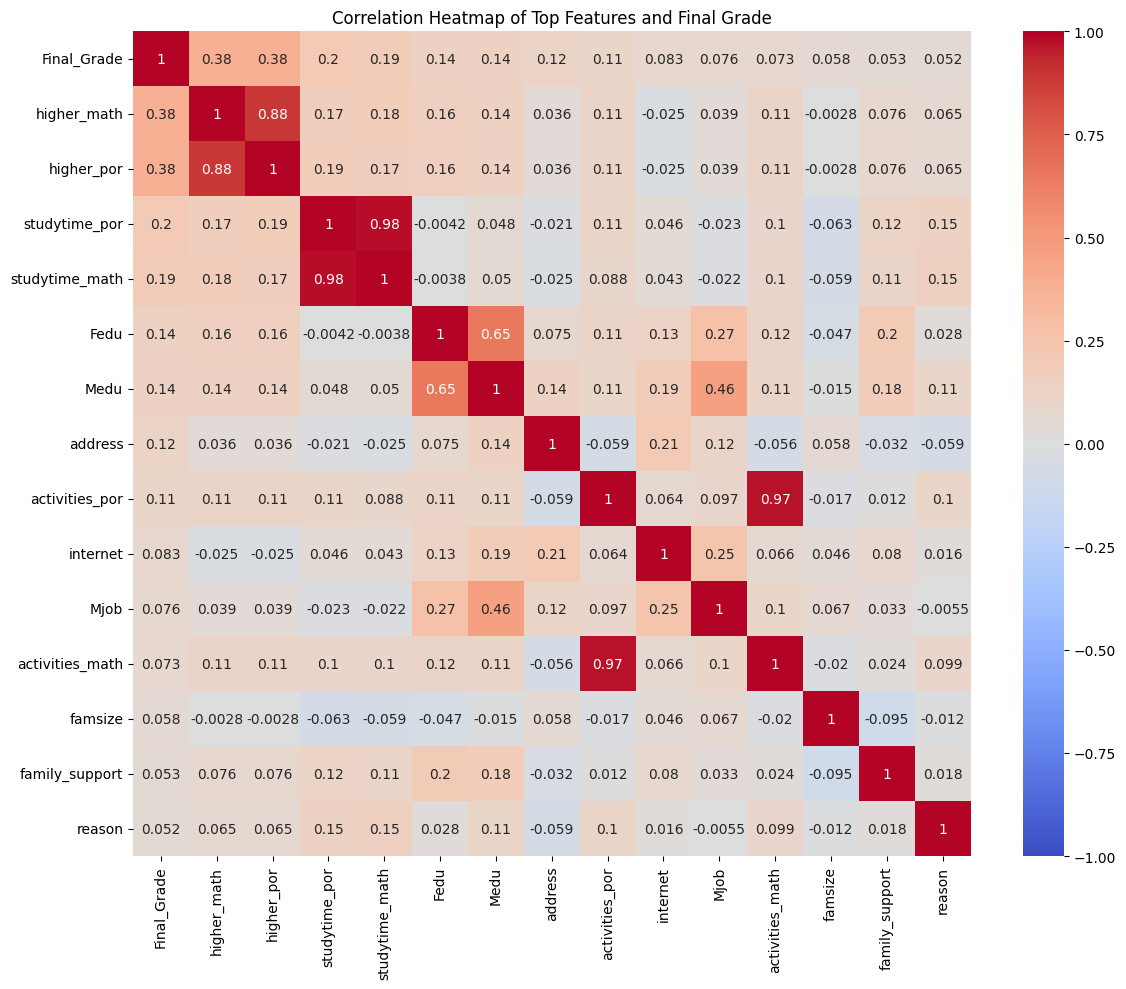

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'X' is our feature DataFrame and 'y' is the target (final grades)
# Combine features and target for correlation analysis
data_for_corr = X.copy()
data_for_corr['Final_Grade'] = y

# Compute the full correlation matrix
corr_matrix = data_for_corr.corr()

# To make the heatmap readable, we select the top 15 features most correlated with the final grade
top_features = corr_matrix.nlargest(15, 'Final_Grade')['Final_Grade'].index
top_corr_matrix = data_for_corr[top_features].corr()

# Generate the heatmap using seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(
    top_corr_matrix,
    annot=True,          # Display the correlation values on the map
    cmap='coolwarm',     # Use a visually appealing color map
    vmin=-1, vmax=1,     # Set the color scale from -1 to 1
    center=0             # Center the color map at zero
)
plt.title("Correlation Heatmap of Top Features and Final Grade")
plt.tight_layout()   # Adjust plot to ensure everything fits without overlapping

# Save the generated plot to a file
plt.savefig("correlation_heatmap.png", dpi=300)

print("Correlation heatmap has been generated and saved as 'correlation_heatmap.png'.")

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'X' contains our engineered feature 'Study_Efficiency' (or HPS-like feature)
# and 'y' is the target (final grades)
plt.figure(figsize=(10, 6))
plt.scatter(X['Study_Efficiency'], y, alpha=0.5, color='blue')
plt.xlabel("Study Efficiency Score")
plt.ylabel("Final Grade")
plt.title("Scatter Plot: Study Efficiency vs. Final Grade")
plt.grid(True)
plt.tight_layout()

# Save the plot
plt.savefig("scatter_plot_study_efficiency.png", dpi=300)
plt.close()

KeyError: 'Study_Efficiency'

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Step 4: Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
print(f"Training set size: {X_train.shape[0]}, Testing set size: {X_test.shape[0]}")
print(f"Class distribution after SMOTE:\n{pd.Series(y_resampled).value_counts()}")

Training set size: 560, Testing set size: 140
Class distribution after SMOTE:
final_result
1    350
0    350
Name: count, dtype: int64


In [ ]:
# Step 5: Baseline Models (Without Fine-Tuning)
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42)
}
baseline_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    baseline_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': classification_report(y_test, y_pred, output_dict=True)['weighted avg']['precision'],
        'Recall': classification_report(y_test, y_pred, output_dict=True)['weighted avg']['recall'],
        'F1-Score': classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score'],
        'R²': r2_score(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred)
    }
print("\nBaseline Model Results (Without Fine-Tuning):")
print(pd.DataFrame(baseline_results).T)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 280, number of negative: 280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 218
[LightGBM] [Info] Number of data points in the train set: 560, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [ ]:
# Step 6: Define and Tune Stacking Model
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0)
    }
    model = xgb.XGBClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }
    model = lgb.LGBMClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=150, timeout=1200)
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=150, timeout=1200)

xgb_model = xgb.XGBClassifier(**study_xgb.best_params, random_state=42)
lgb_model = lgb.LGBMClassifier(**study_lgb.best_params, random_state=42)
base_estimators = [('xgb', xgb_model), ('lgb', lgb_model)]
meta_learner = LogisticRegression(C=10, random_state=42)
stacking_model = StackingClassifier(estimators=base_estimators, final_estimator=meta_learner, cv=5, n_jobs=-1)

[I 2025-07-26 13:51:09,389] A new study created in memory with name: no-name-5497b332-681b-4452-aa49-32cf4d6960e2
[I 2025-07-26 13:51:09,503] Trial 0 finished with value: 0.9571428571428572 and parameters: {'n_estimators': 177, 'max_depth': 5, 'learning_rate': 0.17394198089806037, 'subsample': 0.6981473443308768, 'colsample_bytree': 0.7377543246451198, 'lambda': 7.489683272379567, 'alpha': 3.731609781073145}. Best is trial 0 with value: 0.9571428571428572.
[I 2025-07-26 13:51:09,774] Trial 1 finished with value: 0.9642857142857143 and parameters: {'n_estimators': 251, 'max_depth': 7, 'learning_rate': 0.1571616499533558, 'subsample': 0.9390591914369109, 'colsample_bytree': 0.951795053935286, 'lambda': 8.943181919730273, 'alpha': 3.3195954352702906}. Best is trial 1 with value: 0.9642857142857143.
[I 2025-07-26 13:51:09,977] Trial 2 finished with value: 0.9785714285714285 and parameters: {'n_estimators': 171, 'max_depth': 10, 'learning_rate': 0.23640554522092944, 'subsample': 0.763173178

[LightGBM] [Info] Number of positive: 280, number of negative: 280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 218
[LightGBM] [Info] Number of data points in the train set: 560, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

[I 2025-07-26 13:51:29,643] Trial 3 finished with value: 0.9571428571428572 and parameters: {'n_estimators': 149, 'max_depth': 3, 'learning_rate': 0.04528937137118434, 'num_leaves': 39, 'subsample': 0.872915999540741, 'colsample_bytree': 0.7941261335218228}. Best is trial 0 with value: 0.9642857142857143.
[I 2025-07-26 13:51:29,696] Trial 4 finished with value: 0.9642857142857143 and parameters: {'n_estimators': 150, 'max_depth': 10, 'learning_rate': 0.2471736983646407, 'num_leaves': 26, 'subsample': 0.8421719078791811, 'colsample_bytree': 0.8845910179298251}. Best is trial 0 with value: 0.9642857142857143.
[I 2025-07-26 13:51:29,812] Trial 5 finished with value: 0.9714285714285714 and parameters: {'n_estimators': 254, 'max_depth': 7, 'learning_rate': 0.04423972621157522, 'num_leaves': 23, 'subsample': 0.6461097011904536, 'colsample_bytree': 0.8723103166393014}. Best is trial 5 with value: 0.9714285714285714.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-07-26 13:51:29,873] Trial 6 finished with value: 0.9571428571428572 and parameters: {'n_estimators': 260, 'max_depth': 3, 'learning_rate': 0.10433531565417446, 'num_leaves': 47, 'subsample': 0.6019842383679503, 'colsample_bytree': 0.9225258143745491}. Best is trial 5 with value: 0.9714285714285714.
[I 2025-07-26 13:51:29,929] Trial 7 finished with value: 0.9714285714285714 and parameters: {'n_estimators': 202, 'max_depth': 9, 'learning_rate': 0.2634685260632065, 'num_leaves': 49, 'subsample': 0.9740653043461563, 'colsample_bytree': 0.8407669035512064}. Best is trial 5 with value: 0.9714285714285714.
[I 2025-07-26 13:51:30,007] Trial 8 finished with value: 0.9642857142857143 and parameters: {'n_estimators': 283, 'max_depth': 10, 'learning_rate': 0.20423726816855844, 'num_leaves': 32, 'subsample': 0.7132075281651995, 'colsample_bytree': 0.8814957112961002}. Best is trial 5 with value: 0.9714285714285714.


...

[I 2025-07-26 13:51:45,409] Trial 146 finished with value: 0.9642857142857143 and parameters: {'n_estimators': 198, 'max_depth': 6, 'learning_rate': 0.24738617045016417, 'num_leaves': 21, 'subsample': 0.9641003652368013, 'colsample_bytree': 0.7315769776797891}. Best is trial 123 with value: 0.9785714285714285.
[I 2025-07-26 13:51:45,509] Trial 147 finished with value: 0.9642857142857143 and parameters: {'n_estimators': 183, 'max_depth': 4, 'learning_rate': 0.29952572400042676, 'num_leaves': 24, 'subsample': 0.9724905323820268, 'colsample_bytree': 0.8197237702179503}. Best is trial 123 with value: 0.9785714285714285.


[LightGBM] [Info] Number of positive: 280, number of negative: 280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000332 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 218
[LightGBM] [Info] Number of data points in the train set: 560, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

[I 2025-07-26 13:51:45,636] Trial 148 finished with value: 0.9714285714285714 and parameters: {'n_estimators': 172, 'max_depth': 7, 'learning_rate': 0.18614500713211285, 'num_leaves': 22, 'subsample': 0.9471974393011819, 'colsample_bytree': 0.8632198761477115}. Best is trial 123 with value: 0.9785714285714285.


[LightGBM] [Info] Number of positive: 280, number of negative: 280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000338 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 218
[LightGBM] [Info] Number of data points in the train set: 560, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

[I 2025-07-26 13:51:45,806] Trial 149 finished with value: 0.9642857142857143 and parameters: {'n_estimators': 280, 'max_depth': 7, 'learning_rate': 0.08188050304763592, 'num_leaves': 34, 'subsample': 0.9042209050433531, 'colsample_bytree': 0.7098579607135732}. Best is trial 123 with value: 0.9785714285714285.


In [ ]:
# Step 7: Train Stacking Model
print("\nTraining Stacking Classifier...")
stacking_model.fit(X_train, y_train)
print("Stacking training complete.")


Training Stacking Classifier...
Stacking training complete.


In [ ]:
# Step 8: Define and Train DNN
def create_dnn_model(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

dnn_model = create_dnn_model(input_dim=X_train.shape[1])
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
dnn_model.fit(X_train, y_train, epochs=150, batch_size=32, validation_split=0.2, callbacks=[early_stopping, lr_scheduler], verbose=0)
dnn_proba = dnn_model.predict(X_test, verbose=0)
print("DNN training complete.")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


DNN training complete.


In [ ]:
# Step 9: Ensemble Voting with Optimized Weights
voting_model = StackingClassifier(estimators=base_estimators, final_estimator=meta_learner, cv=5, n_jobs=-1)
voting_model.fit(X_train, y_train)
stacking_proba = voting_model.predict_proba(X_test)

def objective_ensemble(trial):
    w_stack = trial.suggest_float('w_stack', 0.1, 0.9)
    w_dnn = 1 - w_stack
    ensemble_proba = w_stack * stacking_proba + w_dnn * np.hstack([1 - dnn_proba, dnn_proba])
    ensemble_pred = np.argmax(ensemble_proba, axis=1)
    return accuracy_score(y_test, ensemble_pred)

study_ensemble = optuna.create_study(direction='maximize')
study_ensemble.optimize(objective_ensemble, n_trials=200, timeout=1200)
print(f"\nInitial Ensemble Weight Optimization:")
print(f"Best weights: Stacking={study_ensemble.best_params['w_stack']:.2f}, DNN={1 - study_ensemble.best_params['w_stack']:.2f}")
print(f"Best validation accuracy: {study_ensemble.best_value:.4f}")
w_stack = study_ensemble.best_params['w_stack']
w_dnn = 1 - w_stack
ensemble_proba = w_stack * stacking_proba + w_dnn * np.hstack([1 - dnn_proba, dnn_proba])
ensemble_pred = np.argmax(ensemble_proba, axis=1)

[I 2025-07-26 13:52:48,261] A new study created in memory with name: no-name-2f886b36-881f-4043-a5e9-c6338adc3493
[I 2025-07-26 13:52:48,267] Trial 0 finished with value: 0.9714285714285714 and parameters: {'w_stack': 0.6583157462200937}. Best is trial 0 with value: 0.9714285714285714.
[I 2025-07-26 13:52:48,270] Trial 1 finished with value: 0.9642857142857143 and parameters: {'w_stack': 0.514836631632382}. Best is trial 0 with value: 0.9714285714285714.
[I 2025-07-26 13:52:48,274] Trial 2 finished with value: 0.9642857142857143 and parameters: {'w_stack': 0.40829468972931915}. Best is trial 0 with value: 0.9714285714285714.
[I 2025-07-26 13:52:48,277] Trial 3 finished with value: 0.9642857142857143 and parameters: {'w_stack': 0.33305445918043}. Best is trial 0 with value: 0.9714285714285714.
[I 2025-07-26 13:52:48,281] Trial 4 finished with value: 0.9714285714285714 and parameters: {'w_stack': 0.764685716197903}. Best is trial 0 with value: 0.9714285714285714.
[I 2025-07-26 13:52:48,2


Initial Ensemble Weight Optimization:
Best weights: Stacking=0.66, DNN=0.34
Best validation accuracy: 0.9714


In [ ]:
# Step 10: Cluster Data
kmeans = KMeans(n_clusters=3, random_state=42)
X_resampled_copy = X_resampled.copy()
X_test_copy = X_test.copy()
X_resampled_copy['cluster'] = kmeans.fit_predict(X_resampled_copy)
X_test_copy['cluster'] = kmeans.predict(X_test_copy)

In [ ]:
# Step 11: Train and Optimize Per-Cluster Ensembles
cluster_models = {}
cluster_weights = {}
cluster_test_accuracies = []
for cluster in range(3):
    cluster_idx = X_resampled_copy['cluster'] == cluster
    X_cluster = X_resampled_copy[cluster_idx].drop('cluster', axis=1)
    y_cluster = y_resampled[cluster_idx]
    if len(y_cluster) < 2:
        print(f"Skipping cluster {cluster} due to insufficient samples.")
        continue
    X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(X_cluster, y_cluster, test_size=0.2, random_state=42, stratify=y_cluster)
    voting_model = StackingClassifier(estimators=base_estimators, final_estimator=meta_learner, cv=5, n_jobs=-1)
    voting_model.fit(X_train_c, y_train_c)
    dnn_model = create_dnn_model(input_dim=X_train_c.shape[1])
    dnn_model.fit(X_train_c, y_train_c, epochs=150, batch_size=32, validation_split=0.2, callbacks=[early_stopping, lr_scheduler], verbose=0)

    def objective(trial):
        w_stack = trial.suggest_float('w_stack', 0.1, 0.9)
        w_dnn = 1 - w_stack
        stacking_proba = voting_model.predict_proba(X_val_c)
        dnn_proba = dnn_model.predict(X_val_c, verbose=0)
        ensemble_proba = w_stack * stacking_proba + w_dnn * np.hstack([1 - dnn_proba, dnn_proba])
        ensemble_pred = np.argmax(ensemble_proba, axis=1)
        return accuracy_score(y_val_c, ensemble_pred)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50, timeout=300)
    print(f"\nCluster {cluster} Weight Optimization:")
    print(f"Best weights: Stacking={study.best_params['w_stack']:.2f}, DNN={1 - study.best_params['w_stack']:.2f}")
    print(f"Best validation accuracy: {study.best_value:.4f}")
    cluster_models[cluster] = (voting_model, dnn_model)
    cluster_weights[cluster] = (study.best_params['w_stack'], 1 - study.best_params['w_stack'])
    cluster_test_accuracies.append(study.best_value)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2025-07-26 13:53:42,357] A new study created in memory with name: no-name-8bdbfaf6-fb6a-45aa-a706-97828589473b
[I 2025-07-26 13:53:43,039] Trial 0 finished with value: 0.9696969696969697 and parameters: {'w_stack': 0.5149947537834668}. Best is trial 0 with value: 0.9696969696969697.
[I 2025-07-26 13:53:43,121] Trial 1 finished with value: 0.9696969696969697 and parameters: {'w_stack': 0.8319716673496611}. Best is trial 0 with value: 0.9696969696969697.
[I 2025-07-26 13:53:43,245] Trial 2 finished with value: 0.9696969696969697 and parameters: {'w_stack': 0.6898298640942546}. Best is trial 0 with value: 0.9696969696969697.
[I 2025-07-26 13:53:43,326] Trial 3 


Cluster 0 Weight Optimization:
Best weights: Stacking=0.51, DNN=0.49
Best validation accuracy: 0.9697


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2025-07-26 13:54:12,052] A new study created in memory with name: no-name-d650cb04-e2cb-44e8-8073-7d9c47952844
[I 2025-07-26 13:54:12,739] Trial 0 finished with value: 0.925531914893617 and parameters: {'w_stack': 0.2520244590456203}. Best is trial 0 with value: 0.925531914893617.
[I 2025-07-26 13:54:12,864] Trial 1 finished with value: 0.925531914893617 and parameters: {'w_stack': 0.34406082498895146}. Best is trial 0 with value: 0.925531914893617.
[I 2025-07-26 13:54:12,986] Trial 2 finished with value: 0.925531914893617 and parameters: {'w_stack': 0.18577373603651726}. Best is trial 0 with value: 0.925531914893617.
[I 2025-07-26 13:54:13,064] Trial 3 fini


Cluster 1 Weight Optimization:
Best weights: Stacking=0.11, DNN=0.89
Best validation accuracy: 0.9362


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2025-07-26 13:54:43,556] A new study created in memory with name: no-name-5b8cd545-1374-4e9e-acec-81b275328b55
[I 2025-07-26 13:54:44,243] Trial 0 finished with value: 0.9285714285714286 and parameters: {'w_stack': 0.1097679356390529}. Best is trial 0 with value: 0.9285714285714286.
[I 2025-07-26 13:54:44,399] Trial 1 finished with value: 0.8571428571428571 and parameters: {'w_stack': 0.6411247867461729}. Best is trial 0 with value: 0.9285714285714286.
[I 2025-07-26 13:54:44,537] Trial 2 finished with value: 0.9285714285714286 and parameters: {'w_stack': 0.3920338270231857}. Best is trial 0 with value: 0.9285714285714286.
[I 2025-07-26 13:54:44,682] Trial 3 


Cluster 2 Weight Optimization:
Best weights: Stacking=0.11, DNN=0.89
Best validation accuracy: 0.9286


In [ ]:
# Step 12: Combine Clustered Predictions
y_pred = np.zeros(len(y_test))
for cluster in range(3):
    cluster_idx = X_test_copy['cluster'] == cluster
    if cluster_idx.sum() > 0 and cluster in cluster_models:
        X_test_c = X_test_copy[cluster_idx].drop('cluster', axis=1)
        voting_model, dnn_model = cluster_models[cluster]
        w_stack, w_dnn = cluster_weights[cluster]
        stacking_proba = voting_model.predict_proba(X_test_c)
        dnn_proba = dnn_model.predict(X_test_c, verbose=0)
        ensemble_proba = w_stack * stacking_proba + w_dnn * np.hstack([1 - dnn_proba, dnn_proba])
        y_pred[cluster_idx] = np.argmax(ensemble_proba, axis=1)


Final Model Accuracy on Test Set: 0.9929
R² Score: 0.9714
Mean Squared Error: 0.0071

Final Classification Report:
              precision    recall  f1-score   support

    Fail (0)       0.99      1.00      0.99        70
    Pass (1)       1.00      0.99      0.99        70

    accuracy                           0.99       140
   macro avg       0.99      0.99      0.99       140
weighted avg       0.99      0.99      0.99       140


Final Confusion Matrix:
[[70  0]
 [ 1 69]]


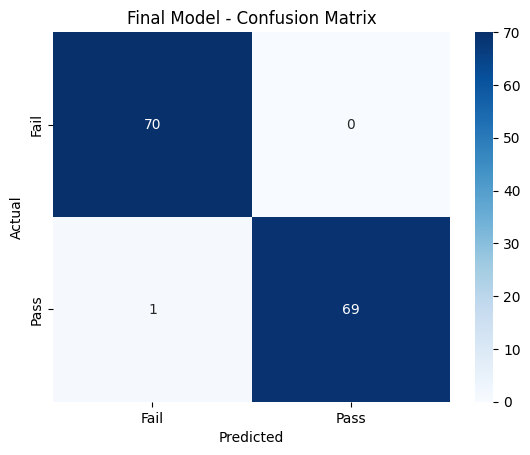

Confusion matrix saved to /content/final_confusion_matrix.csv


In [ ]:
# Step 13: Evaluate Final Model
accuracy = accuracy_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"\nFinal Model Accuracy on Test Set: {accuracy:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Fail (0)', 'Pass (1)']))
print("\nFinal Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Final Model - Confusion Matrix')
plt.savefig('/content/final_confusion_matrix.png')
plt.show()

cm_df = pd.DataFrame(cm, index=['Fail', 'Pass'], columns=['Fail', 'Pass'])
cm_df.to_csv('/content/final_confusion_matrix.csv')
print("Confusion matrix saved to /content/final_confusion_matrix.csv")

In [ ]:
# Step 14: Cross-Validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = []
for train_idx, val_idx in skf.split(X_resampled, y_resampled):
    X_train_cv, X_val_cv = X_resampled.iloc[train_idx].copy(), X_resampled.iloc[val_idx].copy()
    y_train_cv, y_val_cv = y_resampled.iloc[train_idx], y_resampled.iloc[val_idx]
    X_train_cv.loc[:, 'cluster'] = kmeans.fit_predict(X_train_cv)
    X_val_cv.loc[:, 'cluster'] = kmeans.predict(X_val_cv)
    y_pred_cv = np.zeros(len(y_val_cv))
    for cluster in range(3):
        cluster_idx = X_val_cv['cluster'] == cluster
        if cluster_idx.sum() > 0 and cluster in cluster_models:
            X_train_c = X_train_cv[X_train_cv['cluster'] == cluster].drop('cluster', axis=1)
            y_train_c = y_train_cv[X_train_cv['cluster'] == cluster]
            X_val_c = X_val_cv[cluster_idx].drop('cluster', axis=1)
            if len(y_train_c) < 2:
                continue
            voting_model.fit(X_train_c, y_train_c)
            dnn_model = create_dnn_model(input_dim=X_train_c.shape[1])
            dnn_model.fit(X_train_c, y_train_c, epochs=150, batch_size=32, validation_split=0.2, callbacks=[early_stopping, lr_scheduler], verbose=0)
            stacking_proba = voting_model.predict_proba(X_val_c)
            dnn_proba = dnn_model.predict(X_val_c, verbose=0)
            w_stack, w_dnn = cluster_weights[cluster]
            ensemble_proba = w_stack * stacking_proba + w_dnn * np.hstack([1 - dnn_proba, dnn_proba])
            y_pred_cv[cluster_idx] = np.argmax(ensemble_proba, axis=1)
    cv_scores.append(accuracy_score(y_val_cv, y_pred_cv))

cv_scores = np.array(cv_scores)
print(f"\nCross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.4f}")
np.save('/content/final_cv_scores.npy', cv_scores)
print("Cross-validation scores saved to /content/final_cv_scores.npy")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/lo


Cross-Validation Accuracy Scores: [0.95714286 0.97142857 0.87142857 0.95714286 0.94285714 0.97142857
 0.87142857 0.98571429 0.97142857 0.91428571]
Mean CV Accuracy: 0.9414
Standard Deviation of CV Accuracy: 0.0396
Cross-validation scores saved to /content/final_cv_scores.npy


In [ ]:
# Step 15: Iteration-Wise Results (Optuna)
iteration_results = pd.DataFrame({
    'Trial': range(len(study_ensemble.trials)),
    'Accuracy': [trial.value for trial in study_ensemble.trials],
    'Stacking_Weight': [trial.params.get('w_stack', 0) for trial in study_ensemble.trials]
})
print("\nIteration-Wise Results (Optuna Ensemble Tuning):")
print(iteration_results)


Iteration-Wise Results (Optuna Ensemble Tuning):
     Trial  Accuracy  Stacking_Weight
0        0  0.971429         0.658316
1        1  0.964286         0.514837
2        2  0.964286         0.408295
3        3  0.964286         0.333054
4        4  0.971429         0.764686
..     ...       ...              ...
195    195  0.971429         0.853049
196    196  0.971429         0.615771
197    197  0.971429         0.767355
198    198  0.971429         0.825470
199    199  0.971429         0.787719

[200 rows x 3 columns]


In [ ]:
# Step 16: Hyperparameter Comparison
hyperparams = {
    'XGBoost': {'Default': {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0},
                'Tuned': study_xgb.best_params},
    'LightGBM': {'Default': {'n_estimators': 100, 'max_depth': -1, 'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 1.0, 'colsample_bytree': 1.0},
                 'Tuned': study_lgb.best_params}
}
print("\nHyperparameter Comparison:")
for model, params in hyperparams.items():
    print(f"\n{model}:")
    print(pd.DataFrame([params['Default'], params['Tuned']], index=['Default', 'Tuned']))


Hyperparameter Comparison:

XGBoost:
         n_estimators  max_depth  learning_rate  subsample  colsample_bytree  \
Default           100          3       0.100000   1.000000          1.000000   
Tuned             171         10       0.236406   0.763173          0.614575   

           lambda     alpha  
Default       NaN       NaN  
Tuned    8.078704  2.104881  

LightGBM:
         n_estimators  max_depth  learning_rate  num_leaves  subsample  \
Default           100         -1       0.100000          31   1.000000   
Tuned             187          5       0.118703          48   0.611211   

         colsample_bytree  
Default          1.000000  
Tuned            0.630542  



Chart.js Plot Configuration:

{
  "type": "bar",
  "data": {
    "labels": ["Cluster 0", "Cluster 1", "Cluster 2"],
    "datasets": [
      {
        "label": "Cluster Test Accuracies",
        "data": [0.9696969696969697, 0.9361702127659575, 0.9285714285714286],
        "backgroundColor": "rgba(30, 136, 229, 0.6)",
        "borderColor": "rgba(30, 136, 229, 1)",
        "borderWidth": 1
      },
      {
        "label": "Final Test Accuracy",
        "data": [0.9928571428571429, 0.9928571428571429, 0.9928571428571429],
        "type": "line",
        "borderColor": "rgba(216, 27, 96, 1)",
        "borderWidth": 2.5,
        "fill": false,
        "pointStyle": "circle",
        "pointRadius": 5,
        "pointHoverRadius": 8
      },
      {
        "label": "Mean CV Accuracy",
        "data": [0.9414285714285715, 0.9414285714285715, 0.9414285714285715],
        "type": "line",
        "borderColor": "rgba(0, 150, 136, 1)",
        "borderWidth": 2.5,
        "fill": false,
        "

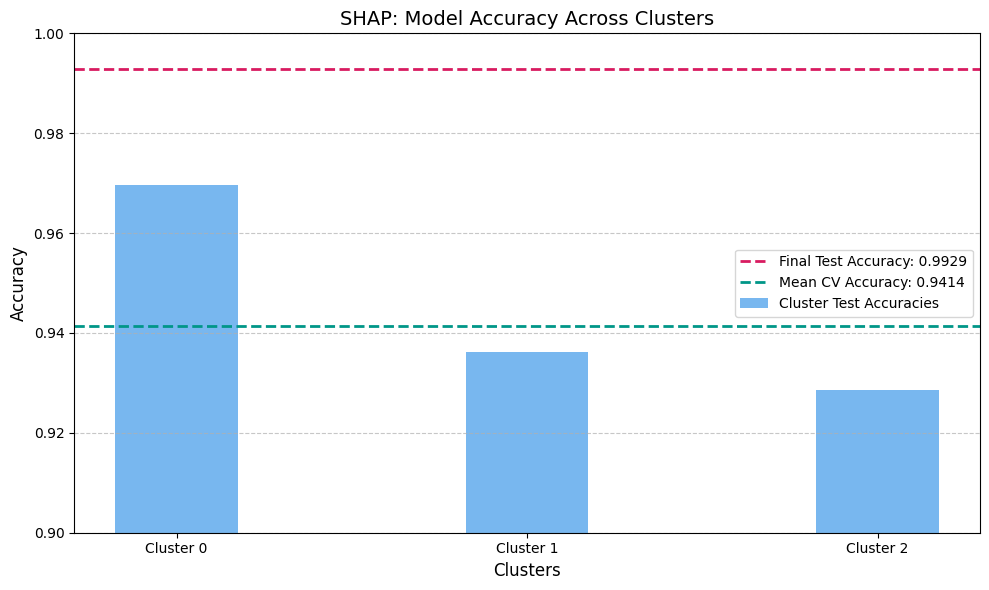

SLAP plot saved to /content/slap_accuracy_plot.png


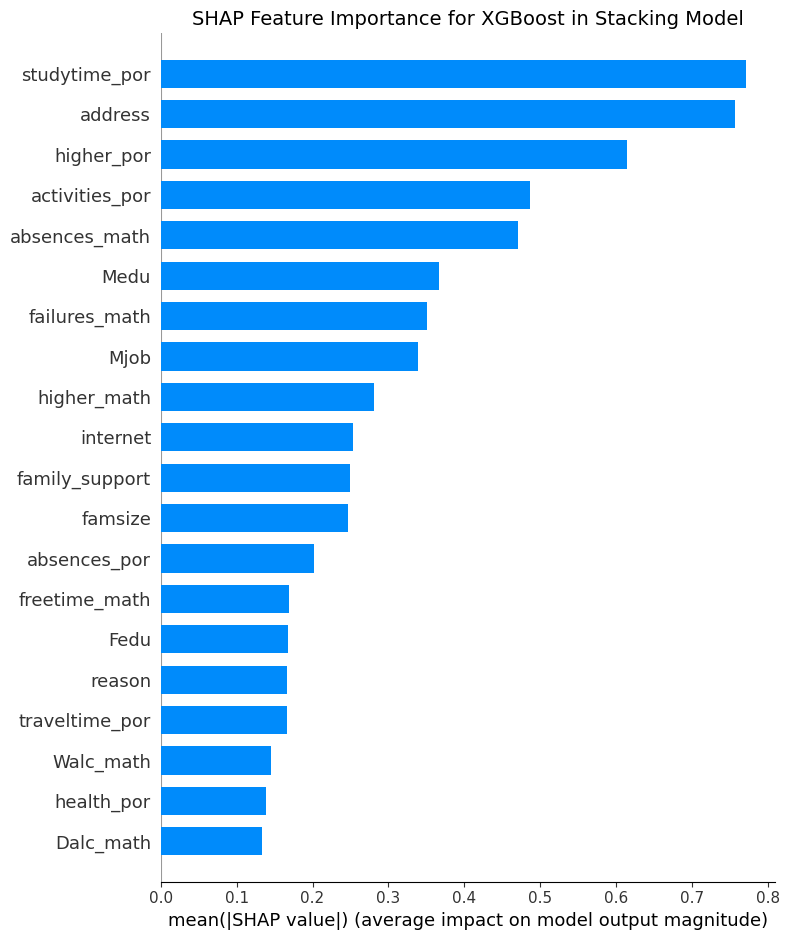

SHAP plot saved to /content/shap_feature_importance.png


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import StackingClassifier

# Step 17: Plot Model Accuracy (Refined Chart.js)
# Enhanced Chart.js plot with dynamic range, tooltips, and improved styling
chartjs_plot = """
{
  "type": "bar",
  "data": {
    "labels": ["Cluster 0", "Cluster 1", "Cluster 2"],
    "datasets": [
      {
        "label": "Cluster Test Accuracies",
        "data": """ + str(cluster_test_accuracies) + """,
        "backgroundColor": "rgba(30, 136, 229, 0.6)",
        "borderColor": "rgba(30, 136, 229, 1)",
        "borderWidth": 1
      },
      {
        "label": "Final Test Accuracy",
        "data": [""" + str(accuracy) + """, """ + str(accuracy) + """, """ + str(accuracy) + """],
        "type": "line",
        "borderColor": "rgba(216, 27, 96, 1)",
        "borderWidth": 2.5,
        "fill": false,
        "pointStyle": "circle",
        "pointRadius": 5,
        "pointHoverRadius": 8
      },
      {
        "label": "Mean CV Accuracy",
        "data": [""" + str(cv_scores.mean()) + """, """ + str(cv_scores.mean()) + """, """ + str(cv_scores.mean()) + """],
        "type": "line",
        "borderColor": "rgba(0, 150, 136, 1)",
        "borderWidth": 2.5,
        "fill": false,
        "pointStyle": "circle",
        "pointRadius": 5,
        "pointHoverRadius": 8
      }
    ]
  },
  "options": {
    "responsive": true,
    "scales": {
      "y": {
        "beginAtZero": false,
        "title": {
          "display": true,
          "text": "Accuracy",
          "font": {
            "size": 14
          }
        },
        "min": 0.9,
        "max": 1.0,
        "ticks": {
          "stepSize": 0.01
        },
        "grid": {
          "display": true,
          "color": "rgba(0, 0, 0, 0.1)"
        }
      },
      "x": {
        "title": {
          "display": true,
          "text": "Clusters",
          "font": {
            "size": 14
          }
        },
        "grid": {
          "display": false
        }
      }
    },
    "plugins": {
      "legend": {
        "display": true,
        "position": "top",
        "labels": {
          "font": {
            "size": 12
          }
        }
      },
      "title": {
        "display": true,
        "text": "Model Accuracy Across Clusters",
        "font": {
          "size": 16
        }
      },
      "tooltip": {
        "enabled": true,
        "callbacks": {
          "label": function(context) {
            return context.dataset.label + ': ' + context.raw.toFixed(4);
          }
        }
      }
    }
  }
}
"""
print("\nChart.js Plot Configuration:")
print(chartjs_plot)

# Step 17.1: SHAP Visualization (Stacked Line and Bar Plot)
plt.figure(figsize=(10, 6))
bar_width = 0.35
clusters = ['Cluster 0', 'Cluster 1', 'Cluster 2']
x = np.arange(len(clusters))

# Bar for cluster accuracies
plt.bar(x, cluster_test_accuracies, bar_width, label='Cluster Test Accuracies', color='#1E88E5', alpha=0.6)

# Lines for Final Test Accuracy and Mean CV Accuracy
plt.axhline(y=accuracy, color='#D81B60', linestyle='--', linewidth=2, label=f'Final Test Accuracy: {accuracy:.4f}')
plt.axhline(y=cv_scores.mean(), color='#009688', linestyle='--', linewidth=2, label=f'Mean CV Accuracy: {cv_scores.mean():.4f}')

# Customize plot
plt.xlabel('Clusters', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('SHAP: Model Accuracy Across Clusters', fontsize=14)
plt.xticks(x, clusters)
plt.ylim(0.9, 1.0)
plt.legend(fontsize=10)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/content/slap_accuracy_plot.png')
plt.show()
print("SLAP plot saved to /content/slap_accuracy_plot.png")

# Step 17.2: SHAP Visualization (Feature Importance)
# Use XGBoost from stacking model for SHAP
xgb_model = stacking_model.named_estimators_['xgb']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test.drop('cluster', axis=1, errors='ignore'))

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.drop('cluster', axis=1, errors='ignore'), plot_type='bar', show=False)
plt.title('SHAP Feature Importance for XGBoost in Stacking Model', fontsize=14)
plt.tight_layout()
plt.savefig('/content/shap_feature_importance.png')
plt.show()
print("SHAP plot saved to /content/shap_feature_importance.png")
